<>:117: SyntaxWarning: invalid escape sequence '\.'
<>:117: SyntaxWarning: invalid escape sequence '\.'
/var/folders/yw/4mwvwkld00722980ghlthxkh0000gn/T/ipykernel_55575/2907495515.py:117: SyntaxWarning: invalid escape sequence '\.'
  home = df[df['MATCHUP'].str.contains('vs\.')]


      Team_ID     Game_ID     GAME_DATE      MATCHUP WL   W   L  W_PCT  MIN  \
0  1610612760  0022501196  APR 12, 2026  OKC vs. PHX  L  64  18  0.780  240   
1  1610612760  0022501182  APR 10, 2026    OKC @ DEN  L  64  17  0.790  240   
2  1610612760  0022501163  APR 08, 2026    OKC @ LAC  W  64  16  0.800  240   
3  1610612760  0022501155  APR 07, 2026    OKC @ LAL  W  63  16  0.797  240   
4  1610612760  0022501139  APR 05, 2026  OKC vs. UTA  W  62  16  0.795  240   

   FGM  ...  FT_PCT  OREB  DREB  REB  AST  STL  BLK  TOV  PF  PTS  
0   41  ...   0.333     9    27   36   32    9    7   10   8  103  
1   42  ...   0.750    15    31   46   25   11    1   13  15  107  
2   48  ...   0.792     6    38   44   30    9    7   13  23  128  
3   45  ...   0.857    10    36   46   29   15    2   12  21  123  
4   54  ...   0.875     8    38   46   40    8    8   15  13  146  

[5 rows x 27 columns]
['Team_ID', 'Game_ID', 'GAME_DATE', 'MATCHUP', 'WL', 'W', 'L', 'W_PCT', 'MIN', 'FGM', 'FGA', '

/var/folders/yw/4mwvwkld00722980ghlthxkh0000gn/T/ipykernel_55575/2907495515.py:27: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['GAME_DATE'] = pd.to_datetime(df['GAME_DATE'])


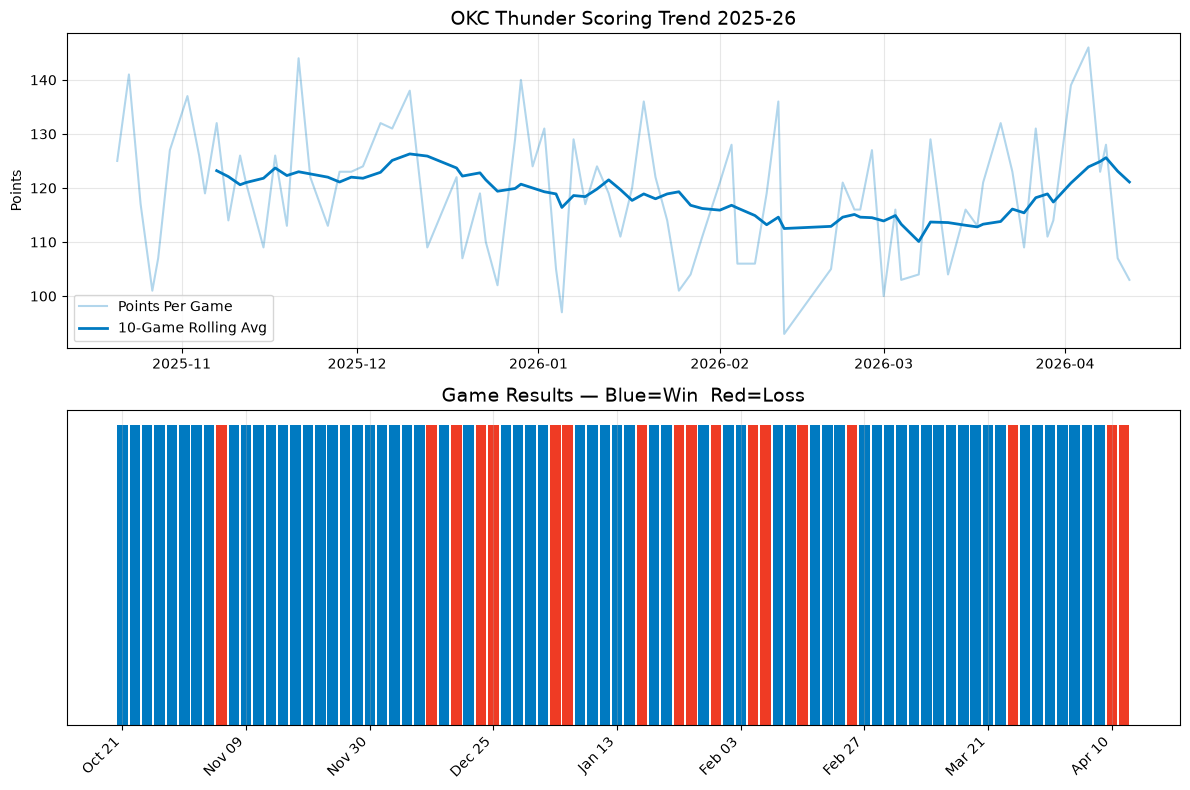

<Figure size 640x480 with 0 Axes>


=== OKC Thunder 2025-26 Analysis ===
Overall Record: 64W-18L
Home Win %: 81.0%
Away Win %: 75.0%
Highest Scoring Game: 146 pts
Lowest Scoring Game: 93 pts
Best Stretch: 126.3 pts avg (10-game peak)
=== OKC Thunder 2025-26 Season Analysis ===

Overall Record: 64W - 18L
Win Percentage: 78.0%

Home Record: 34W - 8L
Away Record: 30W - 10L

Average Points Per Game: 119.0
Highest Scoring Game: 146 pts
Lowest Scoring Game: 93 pts

Peak 10-Game Scoring Avg: 126.3 pts
Lowest 10-Game Scoring Avg: 110.1 pts

January Win Rate: 60.0%
January Avg Points: 116.1


In [9]:
# Cell 1 — Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from nba_api.stats.endpoints import teamgamelog
from nba_api.stats.static import teams
import time

# Cell 2 — Get OKC data
okc = [t for t in teams.get_teams() 
       if t['abbreviation'] == 'OKC'][0]

time.sleep(1)  # API rate limit pause

gamelog = teamgamelog.TeamGameLog(
    team_id=okc['id'],
    season='2025-26',
    season_type_all_star='Regular Season'
)

df = gamelog.get_data_frames()[0]
print(df.head())
print(df.columns.tolist())

# Cell 3 — Clean and explore
df['WL_binary'] = df['WL'].map({'W': 1, 'L': 0})
df['GAME_DATE'] = pd.to_datetime(df['GAME_DATE'])
df = df.sort_values('GAME_DATE')

print(f"Record: {df['WL'].value_counts()['W']}W - {df['WL'].value_counts()['L']}L")
print(f"Average Points: {df['PTS'].mean():.1f}")
print(f"Average Points Allowed: {df['PTS_OPP'].mean():.1f}" 
      if 'PTS_OPP' in df.columns else "")

# Cell 4 — Home vs Away split
home_games = df[df['MATCHUP'].str.contains('vs')]
away_games = df[df['MATCHUP'].str.contains('@')]

print(f"\nHome Record: {home_games['WL'].value_counts()}")
print(f"Away Record: {away_games['WL'].value_counts()}")
print(f"\nHome Avg Points: {home_games['PTS'].mean():.1f}")
print(f"Away Avg Points: {away_games['PTS'].mean():.1f}")

# Cell 5 — Rolling performance visualization
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Points scored rolling average
df['PTS_rolling'] = df['PTS'].rolling(window=10).mean()
axes[0].plot(df['GAME_DATE'], df['PTS'], 
             alpha=0.3, color='#007AC1', label='Points Per Game')
axes[0].plot(df['GAME_DATE'], df['PTS_rolling'], 
             color='#007AC1', linewidth=2, label='10-Game Rolling Avg')
axes[0].set_title('OKC Thunder Scoring Trend 2025-26', fontsize=14)
axes[0].set_ylabel('Points')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Clear the second axes and redraw
axes[1].cla()

win_loss_colors = ['#007AC1' if w == 1 else '#EF3B24' 
                   for w in df['WL_binary']]

# Plot ALL bars at height 1 — color distinguishes wins from losses
axes[1].bar(range(len(df)), 
            [1] * len(df),  # Every bar is height 1
            color=win_loss_colors, 
            width=0.85,
            edgecolor='none')

tick_positions = range(0, len(df), 10)
tick_labels = df['GAME_DATE'].iloc[::10].dt.strftime('%b %d')
axes[1].set_xticks(tick_positions)
axes[1].set_xticklabels(tick_labels, rotation=45, ha='right')

axes[1].set_title('Game Results — Blue=Win  Red=Loss', fontsize=14)
axes[1].set_yticks([])
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('okc_performance.png', dpi=150, bbox_inches='tight')
plt.show()

# Add date labels every 10 games
tick_positions = range(0, len(df), 10)
tick_labels = df['GAME_DATE'].iloc[::10].dt.strftime('%b %d')
axes[1].set_xticks(tick_positions)
axes[1].set_xticklabels(tick_labels, rotation=45, ha='right')

axes[1].set_title('Game Results — Blue=Win  Red=Loss', fontsize=14)
axes[1].set_ylabel('Result')
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(['Loss', 'Win'])
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('okc_performance.png', dpi=150, bbox_inches='tight')
plt.show()

# Cell 6 — Key insights summary
print("\n=== OKC Thunder 2025-26 Analysis ===")
print(f"Overall Record: {df['WL'].value_counts()['W']}W-{df['WL'].value_counts()['L']}L")
print(f"Home Win %: {home_games['WL_binary'].mean():.1%}")
print(f"Away Win %: {away_games['WL_binary'].mean():.1%}")
print(f"Highest Scoring Game: {df['PTS'].max()} pts")
print(f"Lowest Scoring Game: {df['PTS'].min()} pts")
print(f"Best Stretch: {df['PTS_rolling'].max():.1f} pts avg (10-game peak)")
print("=== OKC Thunder 2025-26 Season Analysis ===\n")

# Overall record
wins = df['WL_binary'].sum()
losses = len(df) - wins
print(f"Overall Record: {int(wins)}W - {int(losses)}L")
print(f"Win Percentage: {wins/len(df):.1%}\n")

# Home vs Away
home = df[df['MATCHUP'].str.contains('vs\.')]
away = df[df['MATCHUP'].str.contains('@')]
print(f"Home Record: {int(home['WL_binary'].sum())}W - {int(len(home)-home['WL_binary'].sum())}L")
print(f"Away Record: {int(away['WL_binary'].sum())}W - {int(len(away)-away['WL_binary'].sum())}L\n")

# Scoring stats
print(f"Average Points Per Game: {df['PTS'].mean():.1f}")
print(f"Highest Scoring Game: {df['PTS'].max()} pts")
print(f"Lowest Scoring Game: {df['PTS'].min()} pts\n")

# Best and worst stretches
print(f"Peak 10-Game Scoring Avg: {df['PTS_rolling'].max():.1f} pts")
print(f"Lowest 10-Game Scoring Avg: {df['PTS_rolling'].min():.1f} pts\n")

# January dip analysis
jan = df[df['GAME_DATE'].dt.month == 1]
print(f"January Win Rate: {jan['WL_binary'].mean():.1%}")
print(f"January Avg Points: {jan['PTS'].mean():.1f}")